In [40]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Input, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

In [41]:
# Path to the data folder containing train and test folders

data_folder ='/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset'
# Load the images and labels into lists
images = []
labels = []
folders = os.listdir(data_folder)
class_names = os.listdir(os.path.join(data_folder,folders[-1]))
#class_names.remove('.DS_Store')

print(class_names)

for folder in folders:
    folder_path = os.path.join(data_folder, folder)
    for class_index, class_name in enumerate(class_names):
        class_folder_path = os.path.join(folder_path, class_name)
        print(class_folder_path)
        if class_folder_path.find(".DS") != -1:
          continue
        for filename in os.listdir(class_folder_path):
            if filename.endswith('.jpg'):
                img = load_img(os.path.join(class_folder_path, filename), target_size=(224, 224))
                img_arr = img_to_array(img)
                images.append(img_arr)
                labels.append(class_index)

['pituitary', 'notumor', 'meningioma', 'glioma']
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Training/pituitary
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Training/notumor
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Training/meningioma
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Training/glioma
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Testing/pituitary
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Testing/notumor
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Testing/meningioma
/kaggle/input/brain-tumor-dataset/Brain Tumor Dataset/Testing/glioma


In [42]:
# Convert the lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=4)

# Scale the pixel values to a range between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [43]:
X_test.shape[0]

226

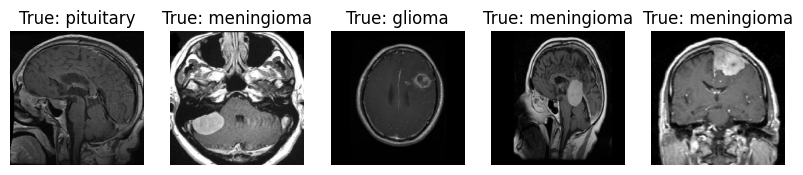

In [44]:
# Display sample images at the beginning
sample_images = X_test[:5]  # Change the number to display more or fewer images
sample_labels = y_test[:5]

plt.figure(figsize=(10, 5))
for i in range(len(sample_images)):
    plt.subplot(1, len(sample_images), i + 1)
    plt.imshow(sample_images[i].reshape(224, 224, 3))
    plt.title(f'True: {class_names[sample_labels[i]]}')
    plt.axis('off')
plt.show()

In [45]:
#to encode labels into numerics
def convert(array):
  encoded = []
  for i in array:
    column  =[0] * len(class_names)
    column[i] = 1
    encoded.append(column)
  return np.array(encoded)

y_train = convert(y_train)
y_test = convert(y_test)

In [46]:
X_train.shape, y_train.shape , X_test.shape, y_test.shape

((904, 224, 224, 3), (904, 4), (226, 224, 224, 3), (226, 4))

In [47]:
y_train[1]

array([0, 0, 1, 0])

In [66]:
# Build the Sequential CNN model-1
model = Sequential()
inputshape = X_train.shape[1:]
#model.add(Input(shape = X_train.shape[1:],))

model.add(Conv2D(16, kernel_size=(3,3), strides=(1,1), padding='valid', activation=tf.keras.layers.LeakyReLU(alpha=0.01), input_shape=inputshape))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))  # Use softmax activation for multi-class classification

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 111, 111, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │    23,888,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,894,308 (91.15 MB)

 Trainable params: 23,894,276 (91.15 MB)

 Non-trainable params: 32 (128.00 B)

In [67]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, batch_size=16, epochs=25, validation_data=(X_test, y_test))


Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.4316 - loss: 17.7279 - val_accuracy: 0.6327 - val_loss: 1.0660
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8167 - loss: 0.4283 - val_accuracy: 0.6327 - val_loss: 0.9385
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9044 - loss: 0.2855 - val_accuracy: 0.6726 - val_loss: 0.7857
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9778 - loss: 0.1175 - val_accuracy: 0.7522 - val_loss: 0.6848
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9792 - loss: 0.0833 - val_accuracy: 0.8186 - val_loss: 0.5532
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9961 - loss: 0.0301 - val_accuracy: 0.7389 - val_loss: 0.5663
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9995 - loss: 0.0146 - val_accuracy: 0.8186 - val_loss: 0.4740
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.8363 -

In [68]:
# Calculating only Test Set Accuracy of the Model
loss, accuracy = model.evaluate(X_test, y_test)

#print(%.3f"Accuracy : {accuracy}")
print('Accuracy : %.3f' % accuracy)

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis =1)
New_y_test = np.argmax(y_test, axis =1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8611 - loss: 0.5685
Accuracy : 0.881
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


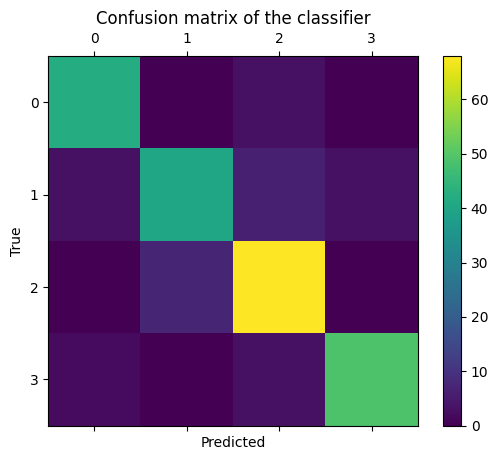

Accuracy :0.8805
0.8842 0.8792 0.8808


In [69]:
"""""""""""""  STEP 4. CALCULATE Model's PERFORMANCE """""""""""""""
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

cm = confusion_matrix(New_y_test, y_pred)
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix of the classifier')
fig.colorbar(cax)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
print("Accuracy :" + str(round(accuracy_score(New_y_test, y_pred),4)))
p, r, f, s = precision_recall_fscore_support(New_y_test, y_pred, average='macro')
print(round(p,4),round(r,4),round(f,4))

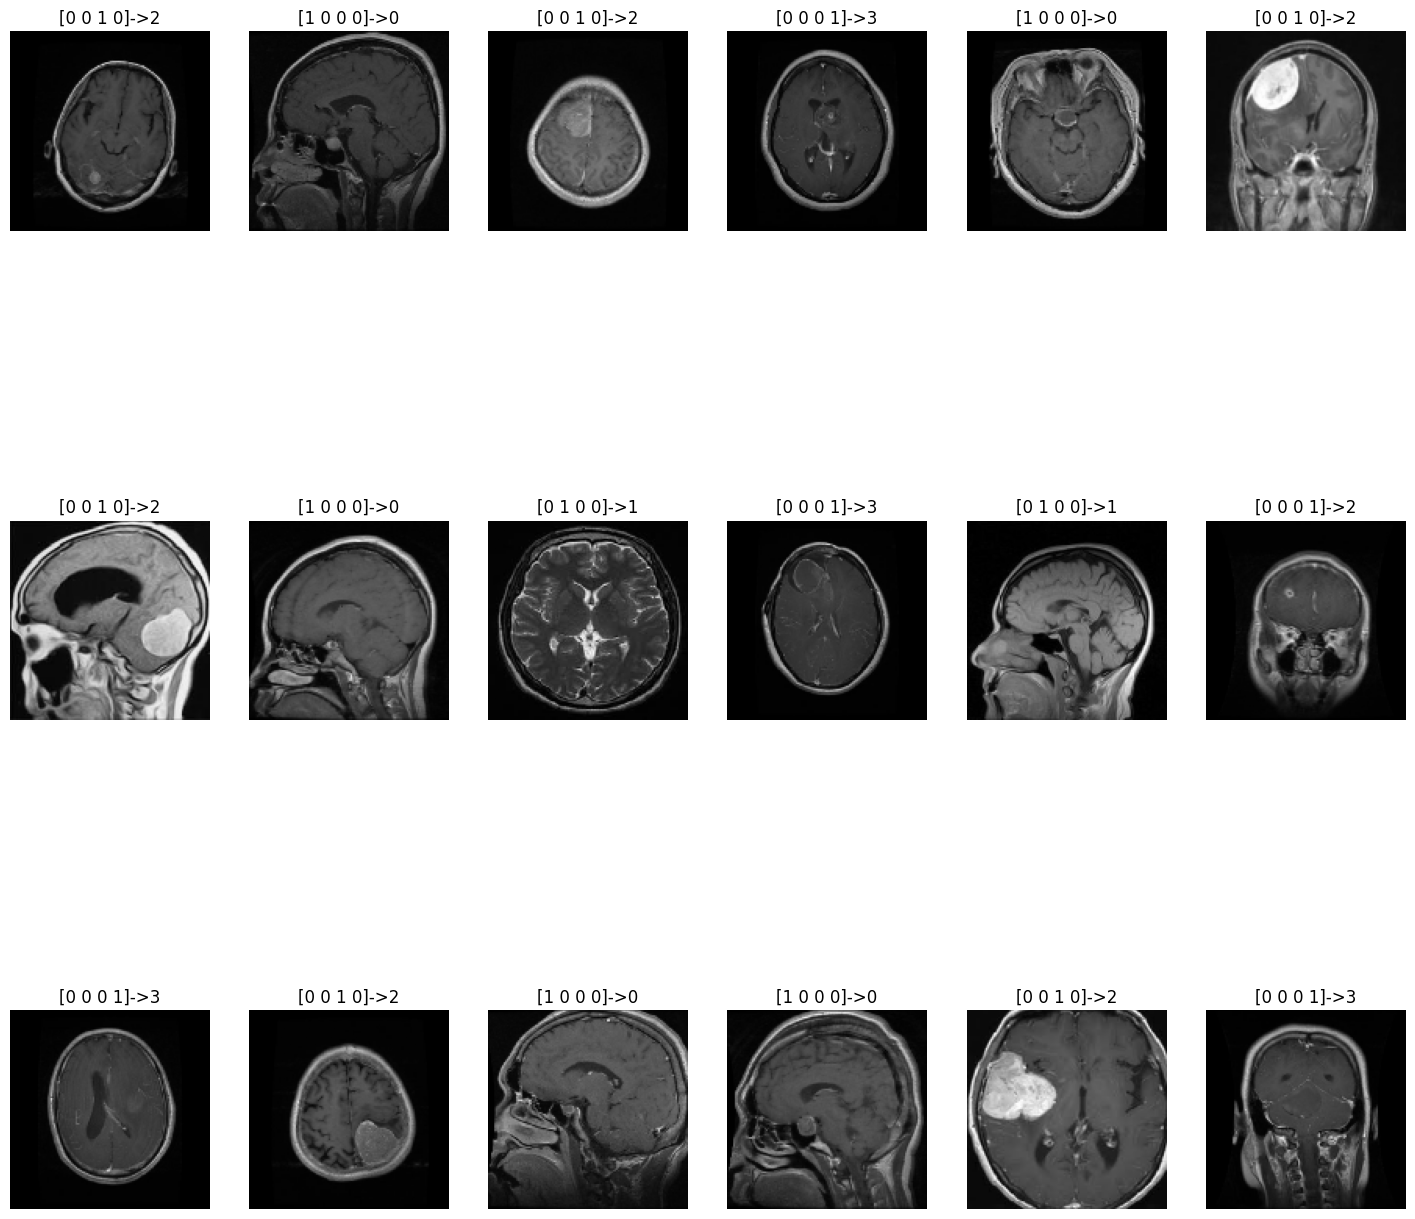

In [29]:
#Visualising the Dataset Samples
import cv2

plt.figure(figsize=(18, 18))
for i in range(18):
  plt.subplot(3, 6, i + 1)
  fignum = np.random.randint(1, high=200)
  plt.imshow(cv2.resize(X_test[fignum], (128, 128)))
  strname = str(y_test[fignum])+"->"+str(y_pred[fignum])
  plt.title(strname)
  plt.axis("off")